<a href="https://colab.research.google.com/github/friedzuccberg/CSC-330-Generative-AI/blob/main/GenAI/Hw4/HWAssignment4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Molly Lonergan

Babak Fourouaghi

**Assignment 4**

**Description**: Analyze and report on Naive, MMR, and Hybrid retrieval techniques and how they affect the accuracy and context awareness of RAG

17 March 2026

In [13]:
!pip install -qU langchain-core langchain-community langchain-google-genai langchain-classic
!pip install -qU faiss-cpu pypdf rank_bm25 flashrank

# Standard imports for environment management
import os
from google.colab import userdata

# API Key from Colab Secrets
os.environ["GOOGLE_API_KEY"] = userdata.get('GOOGLE_API_KEY')


In [14]:
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
import os

# Updated list to match your specific filenames
file_names = [
    "/content/After 8 years, here are the promises Obama kept — and the ones he didn’t - Washington Post.pdf",
    "/content/Barack Obama tan suit controversy - Wikipedia.pdf",
    "/content/Barack Obama_ Campaigns and Elections _ Miller Center.pdf",
    "/content/Barack Obama_ Family Life _ Miller Center.pdf",
    "/content/Obama_WhiteHouse.pdf",
    "/content/President Barack Obama _ Barack Obama Presidential Library.pdf",

]



all_docs = []

# Loop through each file, load its content, and split it into chunks
for file in file_names:
    if os.path.exists(file):
        print(f"Processing {file}...")
        loader = PyPDFLoader(file)

        # Recursive splitter attempts to keep paragraphs and sentences together
        # chunk_size is total characters; overlap keeps context across boundaries
        splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=100)
        chunks = loader.load_and_split(splitter)

        all_docs.extend(chunks)
    else:
        print(f"Warning: '{file}' not found in the sidebar. Please upload it.")

if all_docs:
    print(f"\nSuccess! Total text chunks created: {len(all_docs)}")

Processing /content/After 8 years, here are the promises Obama kept — and the ones he didn’t - Washington Post.pdf...
Processing /content/Barack Obama tan suit controversy - Wikipedia.pdf...
Processing /content/Barack Obama_ Campaigns and Elections _ Miller Center.pdf...
Processing /content/Barack Obama_ Family Life _ Miller Center.pdf...
Processing /content/Obama_WhiteHouse.pdf...
Processing /content/President Barack Obama _ Barack Obama Presidential Library.pdf...

Success! Total text chunks created: 88


In [15]:
import time
from tenacity import retry, stop_after_attempt, wait_random_exponential, retry_if_exception_type
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_community.retrievers import BM25Retriever
from langchain_classic.retrievers import EnsembleRetriever

# Initialize Gemini Embeddings (2026 Stable Model)
embeddings = GoogleGenerativeAIEmbeddings(
    model="models/gemini-embedding-001",
    task_type="retrieval_document"
)



# Define the Retry-Safe Embedding Wrapper
# This function will wait and retry automatically if we get a 429 error.
@retry(
    wait=wait_random_exponential(min=1, max=60),
    stop=stop_after_attempt(5),
    retry=retry_if_exception_type(Exception) # Catch the GoogleGenerativeAIError
)
def embed_with_retry(vector_store, batch):
    if vector_store is None:
        return FAISS.from_documents(batch, embeddings)
    else:
        vector_store.add_documents(batch)
        return vector_store



# Process with Batching and Retries
batch_size = 15 # Smaller batches help prevent hitting the limit too fast
vectorstore = None

print(f"Embedding {len(all_docs)} chunks with rate-limit protection...")
for i in range(0, len(all_docs), batch_size):
    batch = all_docs[i : i + batch_size]
    try:
        vectorstore = embed_with_retry(vectorstore, batch)
        print(f" Processed {i + len(batch)}/{len(all_docs)}...")
    except Exception as e:
        print(f" Failed after retries: {e}")
        break
    time.sleep(3) # A steady 3-second heartbeat to keep the API happy




# Finalize Retrievers
if vectorstore:
  #Trial A
    naive_retriever = vectorstore.as_retriever(search_type="similarity", search_kwargs={
        "k": 5}
        )
  #Trial B
    mmr_retriever = vectorstore.as_retriever(search_type="mmr", search_kwargs={
        "k":5,
        "fetch_k":20})
  # Trial C
    vector_retriever = vectorstore.as_retriever(search_kwargs={"k": 5,"fetch_k":20})
    bm25_retriever = BM25Retriever.from_documents(all_docs)
    bm25_retriever.k = 5

    hybrid_retriever = EnsembleRetriever(
        retrievers=[vector_retriever, bm25_retriever],
        weights=[0.5, 0.5]
    )
    print("\n Retrievers are ready!")


Embedding 88 chunks with rate-limit protection...
 Processed 15/88...
 Processed 30/88...
 Processed 45/88...
 Processed 60/88...
 Processed 75/88...
 Processed 88/88...

 Retrievers are ready!


In [20]:
# Test Queries: Questions for the Retrievers
factual_query = "When was Obama Elected President?"
keyword_query = "Who was Obama married to?"
conceptual_query = "Why was President Obama controversial?"


def test_retriever(query, retriever, name):
    print(f"\n--- Testing: {name} ---")
    print(f"Query: {query}")
    docs =retriever.invoke(query)

    for i, doc in enumerate(docs[:3]): # Show top 3 results
        source = doc.metadata.get('source', 'Unknown')
        # We truncate the content for readability
        content = doc.page_content[:200].replace('\n', ' ')
        print(f"Rank {i+1}: [{source}] {content}...")



# Run the tests for Naive, MMR, and Hybrid
test_retriever(factual_query, naive_retriever, "Naive Retreiver Factual Query")
test_retriever(keyword_query, naive_retriever, "Naive Retreiver Keyword Query")
test_retriever(conceptual_query, naive_retriever, "Naive Retreiver Conceptual Query")

test_retriever(factual_query, mmr_retriever, "MMR Factual Query")
test_retriever(keyword_query, mmr_retriever, "MMR Keyword Query")
test_retriever(conceptual_query, mmr_retriever, "MMR Conceptual Query")

test_retriever(factual_query,  hybrid_retriever, "Hybrid Factual Query")
test_retriever(keyword_query, hybrid_retriever, "Hybrid Keyword Query")
test_retriever(conceptual_query, hybrid_retriever, "Hybrid Conceptual Query")


--- Testing: Naive Retreiver Factual Query ---
Query: When was Obama Elected President?
Rank 1: [/content/President Barack Obama _ Barack Obama Presidential Library.pdf] elected President. He resigned his seat in the U.S. Senate on November 16, 2008. Barack Obama was inaugurated as the 44th President of the United States on January 20, 2009. Presidential Administratio...
Rank 2: [/content/Barack Obama_ Campaigns and Elections _ Miller Center.pdf] nationally televised debates between the presidential candidates that took place from September 26 to October 15, Obama's calm, conﬁdent, and competent demeanor impressed voters who were looking for b...
Rank 3: [/content/Obama_WhiteHouse.pdf] groundbreaking lobbying reform , lock up the world's m ost dangerous weapons, and bring transparency to governm ent by putting federal spending online. He was elected the 44th President of the United ...

--- Testing: Naive Retreiver Keyword Query ---
Query: Who was Obama married to?
Rank 1: [/content/B

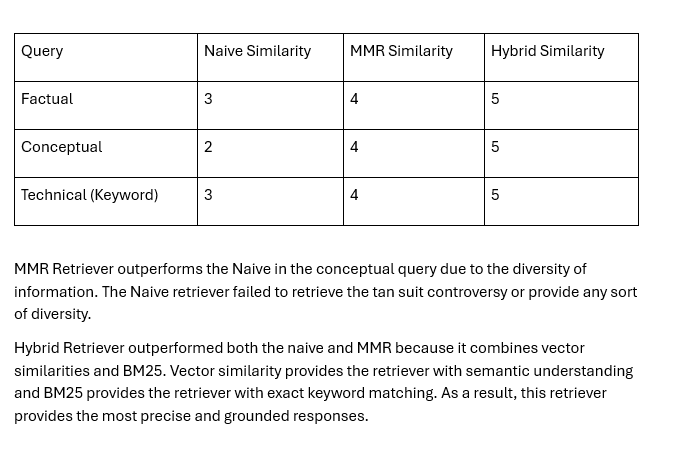

Analysis
1. Comparing Trial A to Trial B, the Naive approach of RAG techniques, returned three chunks with some overlapping content. For example Ranks 1 and 3 returned the information that he was inagurated as the 44th president and the second rank returned information of the dates of his debates. The MMR techniques provided a broader context of the questions adding diversity to it's responses. For example, the MMR technique returned information about the lead up to his presidency such as providing information about his campaigns and elections. As for the conceptual question, the MMR gave a more complete picture because it pulled three distinct controversies: the inauguration, the tan suit, and helping the democrats win more control of the state.
2.  The Hybrid search found information that the vector only searches missed. For example, in the keyword query, the hybrid retrieval returned the exact date they were married along with other relevant information such as the date their children were born and how Obama met  Michelle.
3. If the retrieval failed to find an answer it would return that it didn't have the context to provide an answer. Retrieval quality directly impacts groundedness because of the type and quality of information each technique retrieves. For example, with a more diverse retrieval of information, the LLM's chance of hallucinating lowers, leading to more grounded responses.
4. Based on this specific dataset, the retrieval strategy I would put into production is the Hybrid Techinque. The reasoning behind this choice is because out of all trials, this technique retrieved the most precise information. In the context of a presidential adminstration dataset, precision is the most important when trying to form responses.